In [1]:
import h5py 
import scipy 
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit
from scipy import stats
import os
import spts
import spts.camera
from spts.camera import CXDReader
#import pandas as pd
import sys


In [4]:



def combine_datafiles(filelist): 
    '''
    input:
    filelist - list of directory and filenames of the analysed and to be combined spts.cxi files
    
    output:
    [0]: hits_correctedall - array with length len(filelist)
    [1]: hitxall - array with length len(found particles)
    [2]: hityall - array with length len(found particles)
    [3]: hits_correctedall_single - array with length len(found particles)
    [4]: hitframeall - array with length len(found particles)
    - opens spts.cxi file
    - ignores hits with intensity < 0
    - NO FURTHER REMOVAL OF PARTICLES DONE HERE
    '''
    
    n_data = len(filelist)
    hits_uncorrectedall = []
    hits_corrected = []
    hits_correctedall = []
    hits_correctedall_single = []
    hitxall = []
    hityall = []
    hitframeall = []
    
    for i in range(n_data):
            
        f_name = filelist[i]
        print(i+1, '/',n_data, f_name)

        hits = 0  
        frames = 0 
        hit_intensity = 0 
        hit_intensities = np.empty(shape = (0)) 
        hit_x = np.empty(shape = (0)) # array for storing x-location of hit 
        hit_y = np.empty(shape = (0)) # array for storing y-location of hit 
        hit_frame = np.empty(shape = (0), dtype = int) # array for storing frame number of hits 

        f = h5py.File(f_name, 'r')

        frames += f['/5_detect/n'].shape[0] 
        hits += np.sum(f['/5_detect/n'])
        hits_per_frame = np.array(f["/5_detect/n"])

        #print('Number of frames:', frames) 
        #print('Number of raw hits:', hits) 

        for i in range(0, f['/5_detect/x'].shape[0]): # frame counter 
            for j in range(0, f['/5_detect/n'][i]): # particle counter 
                if f['/6_analyse/peak_sum'][i, j] > 0: # ignore hits with intensity lower than zero 
                    hit_x = np.append(hit_x, f['/5_detect/x'][i, j]) 
                    hit_y = np.append(hit_y, f['/5_detect/y'][i, j]) 
                    hit_frame = np.append(hit_frame, i)
                           
        a = np.array(f['/6_analyse/peak_sum']) 
        real_hits = np.sum((a > 0)) 
        #print('Number of real hits (intensity > 0):', real_hits) 
        #print()
        hit_intensities = np.append(hit_intensities, a[a > 0]) 

        sat_pix = np.array(f["/1_raw/saturated_n_pixels"])
        success_pix = np.array(f["/1_raw/success"])

        num_saturated_pixels = np.sum(sat_pix[sat_pix != 0])

        num_saturated_frames = np.sum(success_pix == 0)
        num_nonsaturated_frames = np.sum(success_pix == 1)

        fraction_saturated = num_saturated_frames / num_nonsaturated_frames

        #print("Number of saturated pixels: %s" % (num_saturated_pixels))
        print("Number of saturated frames: %s/%s" % (num_saturated_frames, frames))
        #print("Number of non-saturated frames: %s/%s" % (num_nonsaturated_frames,frames))
        #print("Percentage of saturated frames: %.4s%%" % (fraction_saturated*100))
    
        av_intensity = np.mean(hit_intensities) 
        med_intensity = np.median(hit_intensities) 
        std_intensity = np.std(hit_intensities) 
        min_intensity = np.min(hit_intensities) 
        max_intensity = np.max(hit_intensities) 
        mad_intensity = scipy.stats.median_abs_deviation(hit_intensities)

        hits_corrected, hitx, hity, hitframe = [], [], [], []
        hits_remain, hits_del = 0, 0
        for h in range(len(hit_intensities)): 
            hit_h = hit_intensities[h] 
            hx, hy, hf = hit_x[h], hit_y[h], hit_frame[h]
            if hit_h >= 0 : 
                hitx.append(hx) 
                hity.append(hy) 
                hitframe.append(hf)
                hits_corrected.append(hit_h) 
                hits_remain += 1
            else:
                hits_del += 1

        hits_corrected = np.array(hits_corrected)
        hitx = np.array(hitx) 
        hity = np.array(hity) 
        hitframe = np.array(hitframe)
            
        hits_correctedall = np.append(hits_correctedall, np.median(hits_corrected**(1/6))) # appends median sixths root intensity
        hits_correctedall_single = np.append(hits_correctedall_single, hits_corrected**(1/6)) # appends all sixths root hit intensities

        hits_uncorrectedall = np.append(hits_uncorrectedall, np.median(hits_corrected))
        #hits_correctedall = np.append(hits_correctedall, np.median(hits_corrected)) # appends median sixths root intensity
        #hits_correctedall_single = np.append(hits_correctedall_single, hits_corrected) # appends all sixths root hit intensities
        
        hitxall = np.append(hitxall, hitx) # all hit x-positions
        hityall = np.append(hityall, hity) # all hit y-positions
        hitframeall = np.append(hitframeall, hitframe) # all hit frame numbers
        
    return hits_correctedall, hitxall, hityall, hits_correctedall_single, hitframeall, hits_uncorrectedall


def linear(x, a):
    return a*x

def linear_b(x, a, b):
    return a*x + b




In [5]:

#combining and creating a dataset from the spts.cxi data files for each particle size and size window. 
#20 nm:
PS20 = combine_datafiles([f'/home/tejvarmay/scattering_data/data/newdata/data00{i}_analysis_d15/spts.cxi' for i in range(431,436)])
PS202 = combine_datafiles([f'/home/tejvarmay/scattering_data/data/newdata/data00{i}_analysis_d5/spts.cxi' for i in range(431,436)])

#30 nm:
PS30 = combine_datafiles([f'/home/tejvarmay/scattering_data/data/newdata/data00{i}_analysis_d15/spts.cxi' for i in range(415,420)])
PS302 = combine_datafiles([f'/home/tejvarmay/scattering_data/data/newdata/data00{i}_analysis_d5/spts.cxi' for i in range(415,420)])
#40 nm:
PS40 = combine_datafiles([f'/home/tejvarmay/scattering_data/data/newdata/data00{i}_analysis_d15/spts.cxi' for i in range(408,413)])
PS402 = combine_datafiles([f'/home/tejvarmay/scattering_data/data/newdata/data00{i}_analysis_d5/spts.cxi' for i in range(408,413)])
#50 nm:
PS50 = combine_datafiles([f'/home/tejvarmay/scattering_data/data/newdata/data00{i}_analysis_d15/spts.cxi' for i in range(395,400)])
PS502 = combine_datafiles([f'/home/tejvarmay/scattering_data/data/newdata/data00{i}_analysis_d5/spts.cxi' for i in range(395,400)])

print("done.")

1 / 5 /home/tejvarmay/scattering_data/data/newdata/data00431_analysis_d15/spts.cxi
Number of saturated frames: 2/2000
2 / 5 /home/tejvarmay/scattering_data/data/newdata/data00432_analysis_d15/spts.cxi
Number of saturated frames: 0/2000
3 / 5 /home/tejvarmay/scattering_data/data/newdata/data00433_analysis_d15/spts.cxi
Number of saturated frames: 0/2000
4 / 5 /home/tejvarmay/scattering_data/data/newdata/data00434_analysis_d15/spts.cxi
Number of saturated frames: 0/2000
5 / 5 /home/tejvarmay/scattering_data/data/newdata/data00435_analysis_d15/spts.cxi
Number of saturated frames: 1/2000
1 / 5 /home/tejvarmay/scattering_data/data/newdata/data00431_analysis_d5/spts.cxi
Number of saturated frames: 2/2000
2 / 5 /home/tejvarmay/scattering_data/data/newdata/data00432_analysis_d5/spts.cxi
Number of saturated frames: 0/2000
3 / 5 /home/tejvarmay/scattering_data/data/newdata/data00433_analysis_d5/spts.cxi
Number of saturated frames: 0/2000
4 / 5 /home/tejvarmay/scattering_data/data/newdata/data0043

In [20]:


def big_plot(sample, sample2, Limit=0.9, Limitup=260, Limitdown=160, limdown_intensity=0,plotfigs=True, sixth_root=True ):
    #smps = 4
    #limup =     [0,0,0,0] # use limitup value for each dataset ex 20,30,40, 50 nm
    #limdown =   [0,0,0,0] # use limitdown value for each dataset ex 20,30,40, 50 nm
    #limdown_intensity = [3,3,5,7]   #custom lower limit for the intensity for a particle to have to be considered focused
    #detailed_view = True    #true if you want to detailed scatter plot (focused/focused_out/unfocused differentiation)
    #pos2intensity = True    #true if you want to plot the intensity of the focused particles according to their y position
    print(sample)

    sample_focus_ind = 3

    focused = []
    focused_pa = []
    focused_out = []
    focused_out_pa = []
    unfocused = []
    unfocused_pa = []
    discard = []
    foc_x = []; foc_y = []; unfoc_x = []; unfoc_y = []; focout_x = []; focout_y = []
    j = 0
    for i in range(len(sample[4])-1):
        if sample[4][i] == sample2[4][i]:
            if sample[1][i] == sample2[1][i]:
                #print(PS50[3][i], PS502[3][i])
                if sample[sample_focus_ind][i] >= sample2[sample_focus_ind][i] >= Limit*sample[sample_focus_ind][i]:
                 #   print("focused")
                    if (sample[2][i]<Limitup)&(sample[2][i]>Limitdown):
                        
                        #custom intensity limits
                        if limdown_intensity == 0:
                            focused = np.append(focused, sample[sample_focus_ind][i])
                            
                            foc_x = np.append(foc_x, sample[1][i])
                            foc_y = np.append(foc_y, sample[2][i])
                        else:
                            if sample[sample_focus_ind][i] >= limdown_intensity:
                                focused = np.append(focused, sample[sample_focus_ind][i])
                            
                                foc_x = np.append(foc_x, sample[1][i])
                                foc_y = np.append(foc_y, sample[2][i])
                            else:
                                discard = np.append(discard, sample[sample_focus_ind][i])
                    else:
                        focused_out = np.append(focused_out, sample[sample_focus_ind][i])
                        
                        focout_x = np.append(focout_x, sample[1][i])
                        focout_y = np.append(focout_y, sample[2][i])

                else:
                   # print("unfocused")
                    unfocused = np.append(unfocused, sample[sample_focus_ind][i])
                    unfoc_x = np.append(unfoc_x, sample[1][i])
                    unfoc_y = np.append(unfoc_y, sample[2][i])
        else:
            try:
                j = np.where(sample2[4] == sample[4][i])[0][0]  #index, where the small circle data == large circle data, 
                                                                # j = 2, i = 0
            except:
                k = 0


            if sample[1][i] == sample2[1][j]:
                if sample[sample_focus_ind][i] >= sample2[sample_focus_ind][j] >= Limit*sample[sample_focus_ind][i]:
                    #print("focused")
                    if (sample[2][i]<Limitup)&(sample[2][i]>Limitdown):

                        #custom intensity limits
                        if limdown_intensity == 0:
                            focused = np.append(focused, sample[sample_focus_ind][i])
                            
                            foc_x = np.append(foc_x, sample[1][i])
                            foc_y = np.append(foc_y, sample[2][i])
                        else:
                            if sample[sample_focus_ind][i] >= limdown_intensity:
                                focused = np.append(focused, sample[sample_focus_ind][i])
                                
                                foc_x = np.append(foc_x, sample[1][i])
                                foc_y = np.append(foc_y, sample[2][i])
                            else:
                                discard = np.append(discard, sample[sample_focus_ind][i])
                    else:
                        focused_out = np.append(focused_out, sample[sample_focus_ind][i])
                        
                        focout_x = np.append(focout_x, sample[1][i])
                        focout_y = np.append(focout_y, sample[2][i])
                else:
                    #print("unfocused")
                    unfocused = np.append(unfocused, sample[3][i])
                    
                    unfoc_x = np.append(unfoc_x, sample[1][i])
                    unfoc_y = np.append(unfoc_y, sample[2][i]) 

        #print("frame number of focused hits:", sample[4][i])
        


    print(f" #focused: {len(focused)}, #focused out: {len(focused_out)}, #unfocused: {len(unfocused)}, #discarded: {len(discard)}")

    if plotfigs:
        plt.figure()
        plt.hist(focused, bins = 80, range = (0,16), color = "black", label = "focused in region of interest", histtype = 'step')
        plt.hist(focused_out, bins = 80, range = (0,16), color = "gray", label = "focused out of region of interest", histtype = 'step')
        plt.hist(unfocused, bins = 80, range = (0,16), color = "red", label = "unfocused", histtype = 'step')
        #plt.title(F"intensity distribution of focused particles, {list(files_w05.keys())[m]}")
        plt.xlabel("scat. $I^{1/6}$ (A.U.)")
        plt.ylabel("counts")
        plt.legend()
        plt.show()
        plt.figure()
        plt.scatter(sample[1], sample[2])
        plt.hlines(Limitup, 0, 500, color = "red", ls = "--", alpha = 0.5)
        plt.hlines(Limitdown, 0, 500, color = "red", ls = "--", alpha = 0.5)
        
        plt.scatter(unfoc_x,    unfoc_y,    color = "red", label = "unfocused", alpha = 0.2)
        plt.scatter(focout_x,   focout_y,   color = "yellow", label = "focused out of region of interest")
        plt.scatter(foc_x,      foc_y,      color = "green", label = "focused in region of interest", alpha = 0.2)
        plt.ylabel("particle propagation axis (px)")
        plt.xlabel("laser propagation axis (px)")
        #plt.title(F"position of all particles, {list(files_w05.keys())[m]}")
        plt.legend()
        plt.show()

    #plot the intensity of the focused particles according to y position
  
        plt.figure()
        plt.scatter(focused, foc_y, color = "green", label = "focused in region of interest")
        plt.scatter(focused_out, focout_y, color = "yellow", label = "focused out of region of interest")
        #plt.scatter(unfocused, unfoc_y, color = "red", label = "focused out of region of interest")
        plt.title("Y position according to intensity")
        plt.hlines(Limitup,   np.min(focused), np.max(focused), color = "red", ls = "--", alpha = 0.5)
        plt.hlines(Limitdown, np.min(focused), np.max(focused), color = "red", ls = "--", alpha = 0.5)
        plt.xlabel("scat. $I^{1/6}$ (A.U.)")
        plt.ylabel("y-position (px)")
        #plt.figure()
        #plt.hist2d(foc_x, foc_y, weights=focused, bins=[50, 50], cmap='viridis')

    
    #peak position of distribution: 
    histogram = np.histogram(focused_pa, bins = 160, range = (0,16))
    peak = histogram[1][np.argmax(histogram[0])]

    #if m == 3:
    #    peak = histogram[1][np.where(histogram[0] == np.max(histogram[0][25:]))]
    
    print("peak intensity of focused particles: ", peak)
    print("median position:", np.median(focused))    
#    plt.figure()
#    plt.title("position of all particles y-position")
#    plt.scatter(sample[1], sample[2])
#    plt.show()
    
    print("--------------------")   


    if len(focused) == 0:
        focused = np.append(focused, 0)

    return focused
    #return np.median(focused), np.mean(focused), np.std(focused), scipy.stats.median_abs_deviation(focused)
    #intensity_median = np.append(intensity_median, np.median(focused))
    #intensity_mean = np.append(intensity_mean, np.mean(focused))
    #intensity_std = np.append(intensity_std, np.std(focused))
    #intensity_mad = np.append(intensity_mad, scipy.stats.median_abs_deviation(focused))
    

In [21]:
PS20

(array([3.8841694 , 3.86896836, 3.86608255, 3.87071809, 3.82105453]),
 array([305.45454545, 185.89473684, 237.48803828, ..., 246.37162162,
        218.12      , 198.98089172]),
 array([197.51748252,  93.57894737, 130.98564593, ...,  79.15540541,
        110.72      ,  93.18471338]),
 array([4.87446651, 4.27394596, 5.12712904, ..., 4.33910625, 3.39278741,
        4.68274042]),
 array([   8.,    9.,    9., ..., 1972., 1972., 1974.]),
 array([3433.91052246, 3354.06188965, 3339.0793457 , 3363.17333984,
        3112.42871094]))

(array([3.8841694 , 3.86896836, 3.86608255, 3.87071809, 3.82105453]), array([305.45454545, 185.89473684, 237.48803828, ..., 246.37162162,
       218.12      , 198.98089172]), array([197.51748252,  93.57894737, 130.98564593, ...,  79.15540541,
       110.72      ,  93.18471338]), array([4.87446651, 4.27394596, 5.12712904, ..., 4.33910625, 3.39278741,
       4.68274042]), array([   8.,    9.,    9., ..., 1972., 1972., 1974.]), array([3433.91052246, 3354.06188965, 3339.0793457 , 3363.17333984,
       3112.42871094]))
 #focused: 92, #focused out: 181, #unfocused: 1161, #discarded: 0


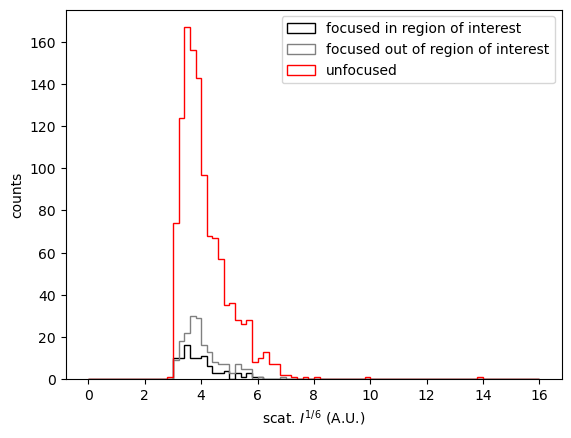

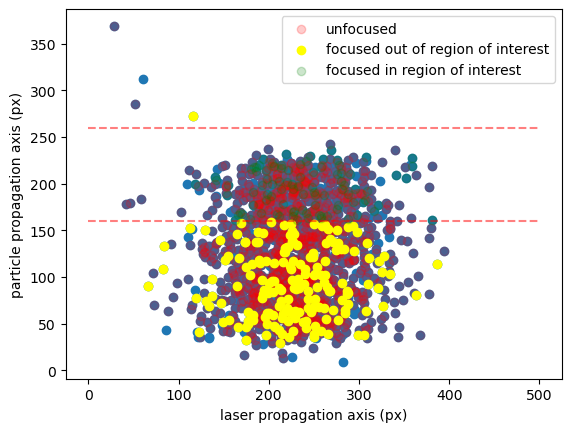

peak intensity of focused particles:  0.0
median position: 3.797306076068571
--------------------
(array([4.79364264, 4.73807015, 4.69863896, 4.73906217, 4.71055274]), array([186.6875    , 216.67857143, 169.1827957 , ..., 228.56884422,
       229.68444444, 184.8951049 ]), array([ 94.02083333,  66.07142857, 224.25806452, ..., 213.75879397,
       145.75555556, 126.48951049]), array([3.7400507 , 3.47011261, 4.69244283, ..., 5.10147044, 5.95377415,
       4.64454363]), array([   3.,    4.,    4., ..., 1990., 1994., 1996.]), array([12133.71887207, 11313.99212646, 10760.50170898, 11328.03125   ,
       10925.29296875]))
 #focused: 374, #focused out: 382, #unfocused: 2959, #discarded: 0


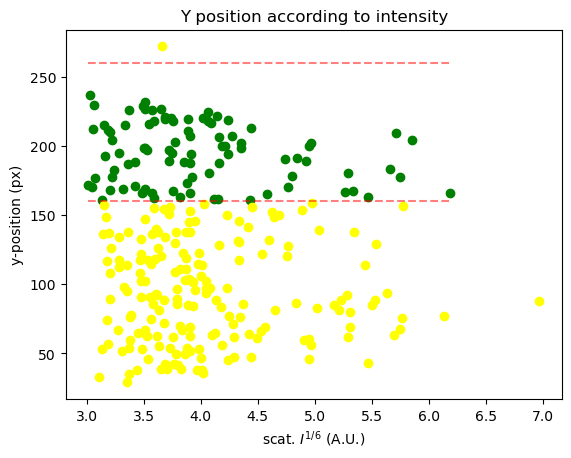

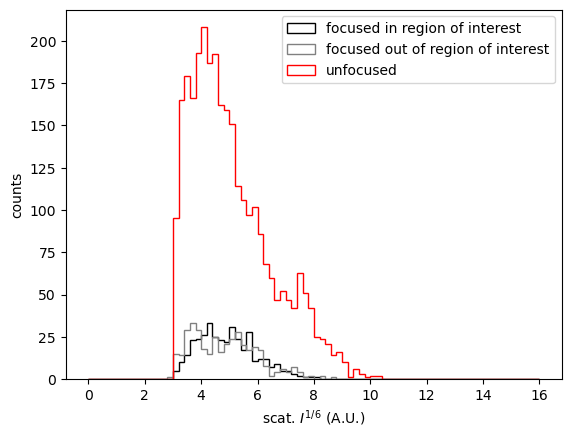

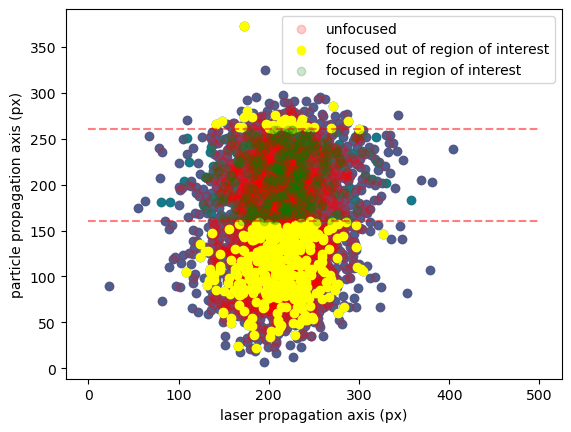

peak intensity of focused particles:  0.0
median position: 4.840654864612404
--------------------
(array([5.23569504, 5.33533788, 5.37885346, 5.25985762, 5.28896858]), array([200.68888889, 263.84987277, 285.        , ..., 186.21083172,
       186.64550265, 193.47457627]), array([147.0037037 , 203.53689567, 122.5       , ..., 173.00580271,
       117.64021164, 165.93220339]), array([5.52479933, 9.50589929, 3.40918008, ..., 8.55849634, 5.10208526,
       4.07181258]), array([1.000e+00, 1.000e+00, 2.000e+00, ..., 1.991e+03, 1.998e+03,
       1.999e+03]), array([20599., 23066., 24218., 21176., 21889.]))
 #focused: 84, #focused out: 248, #unfocused: 1536, #discarded: 22


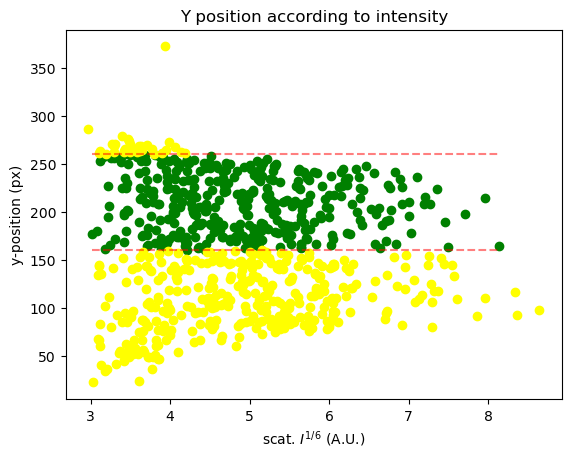

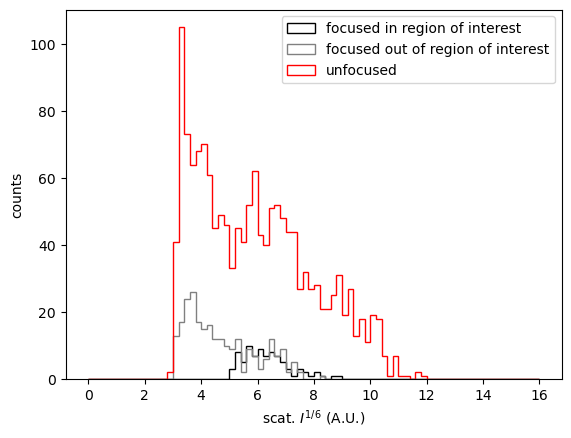

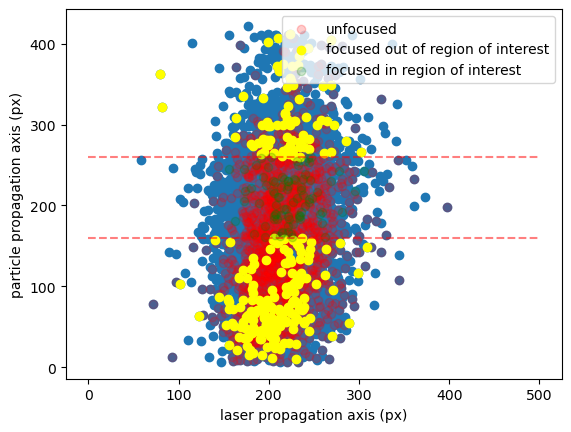

peak intensity of focused particles:  0.0
median position: 6.208305169347902
--------------------
(array([4.57445768, 4.52960662, 4.34673995, 4.62590766, 4.54133044]), array([230.87286064, 228.39005736, 198.52      , ..., 188.38053097,
       278.17315716, 242.5       ]), array([221.41564792, 241.34608031,  60.625     , ...,  63.0619469 ,
       167.74130737, 178.25      ]), array([ 8.42921928,  8.76805049,  6.10619286, ...,  5.29302816,
       11.60126507,  3.8802173 ]), array([   0.,    6.,    7., ..., 1997., 1999., 1999.]), array([9163., 8637., 6745., 9799., 8772.]))
 #focused: 9, #focused out: 194, #unfocused: 1212, #discarded: 13


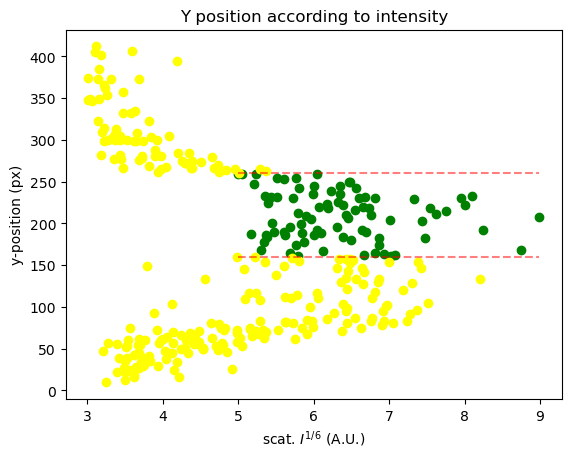

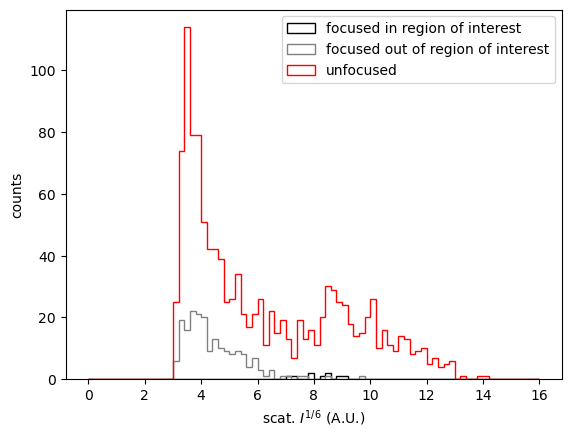

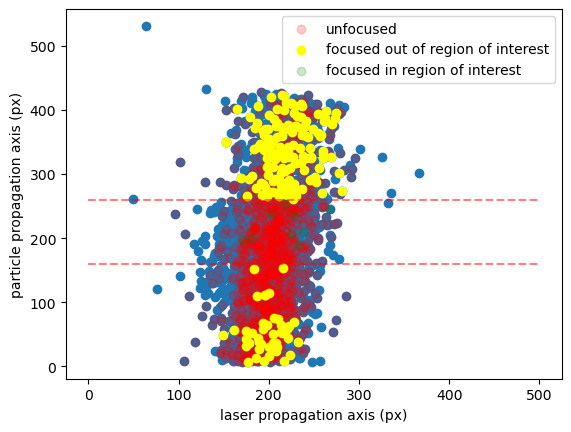

peak intensity of focused particles:  0.0
median position: 8.206569738584342
--------------------


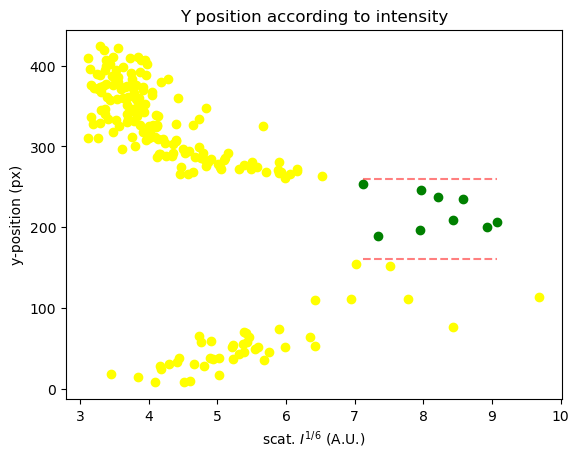

In [27]:
plotfigs = True
sixth_root=  False
focus1 = big_plot(PS20,PS202, limdown_intensity=3, plotfigs=plotfigs, sixth_root=sixth_root)
focus2 = big_plot(PS30,PS302, limdown_intensity=3, plotfigs=plotfigs, sixth_root=sixth_root)
focus3 = big_plot(PS40,PS402, limdown_intensity=5, plotfigs=plotfigs, sixth_root=sixth_root)
focus4 = big_plot(PS50,PS502, limdown_intensity=7, plotfigs=plotfigs, sixth_root=sixth_root)
#focus1 = big_plot(PS20,PS202, limdown_intensity=3, Limitdown=75, Limitup=175, plotfigs=plotfigs)
#focus2 = big_plot(PS30,PS302, limdown_intensity=3, Limitdown=75, Limitup=225, plotfigs=plotfigs)
#focus3 = big_plot(PS40,PS402, limdown_intensity=5, Limitdown=100, Limitup=300, plotfigs=plotfigs)
#focus4 = big_plot(PS50,PS502, limdown_intensity=7, Limitdown=100, Limitup=325, plotfigs=plotfigs)

In [23]:
#intensity_median = [np.median(focus1), ];intensity_mean = [];intensity_std = [];intensity_mad = [];
intensity_median = list(map(np.median, [focus1,focus2,focus3,focus4]))
intensity_mean = list(map(np.mean, [focus1,focus2,focus3,focus4]))
intensity_std = list(map(np.std, [focus1,focus2,focus3,focus4]))
intensity_mad = list(map(scipy.stats.median_abs_deviation, [focus1,focus2,focus3,focus4]))

In [24]:
intensity_median

[3.797306076068571, 4.840654864612404, 6.208305169347902, 8.206569738584342]

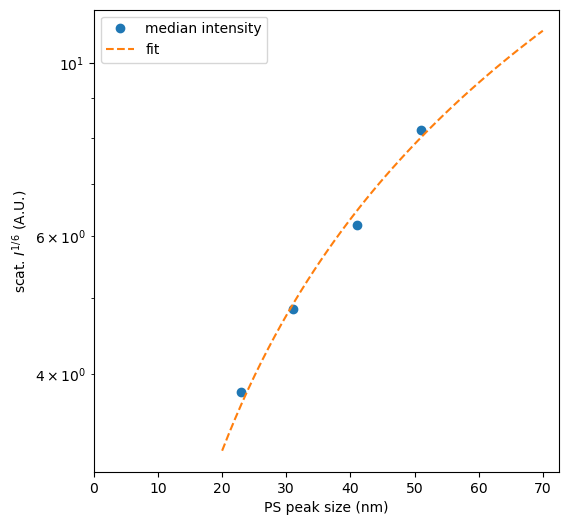

In [25]:
UseOffset = False
 
diameter = np.array([23, 31, 41, 51]) #peak diameter from DMA histogram

def sixth_root(x, a):
    return a*(x)**(1/6)

def linearb(x, a, b):
    return a*x+b

def linear0(x,a):
    return a*x

fitfn = linearb


popt, pcov = scipy.optimize.curve_fit(fitfn, diameter, intensity_median)

perr = np.sqrt(np.diag(pcov)) #one standard deviation error
diams = np.linspace(20, 70)

plt.figure(figsize = (6, 6))
plt.plot(diameter, intensity_median, 'o', label = "median intensity") 
plt.plot(diams, fitfn(diams, *popt), '--', label = "fit")
#plt.plot(diams, a_parts*diams+b_parts, '--', label = "linear fit")

plt.xlabel("PS peak size (nm)") 
plt.ylabel("scat. $I^{1/6}$ (A.U.)")
plt.legend()
plt.xticks(np.arange(0,71, 10))
plt.yscale('log')

#plt.ylim(0, 13)
#plt.savefig("intensity_calibration_BRIO.pdf")
plt.show()
 

#print("Linear fit summary:")
##print("------------------------------------------------------")
#print('slope:', a_parts) 
#print('offset:', b_parts)
#print('error:', perr)
#print("------------------------------------------------------")
#print() 

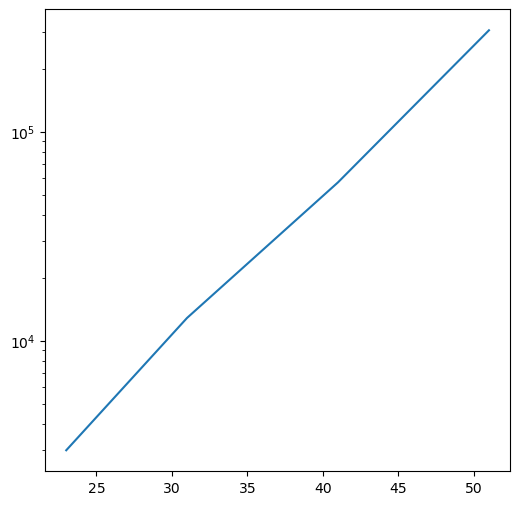

In [26]:
diameter = np.array([23, 31, 41, 51]) #peak diameter from DMA histogram
intensity_pow = np.array(intensity_median)**6
plt.figure(figsize = (6, 6))
plt.plot(diameter, intensity_pow)
plt.yscale('log')